# Forecasting Model for Titanic Passengers

## Objective

The project objective is to predict the survival rate of a passenger based on his or her sex, passenger class, and so on. Hence, this model can be apply to predict the survival state of some missing passengers.

## Basic Info

The dataset includes two tables: `titianic_train.csv` and `titanic_test.csv`.

`titianic_train.csv` records the information of over 800 passengers and their survival state.
`titanic_test.csv` records the information of some passengers whose survival state is unknown. 

The meaning of each column in`titianic_train.csv`:
- PassengerId: Passenger ID
- survival: Survived or not
   - 0	No
   - 1	Yes
- pclass: Passenger Class
   - 1	First Class
   - 2	Second Class
   - 3  Third Class
- sex: Gender of the passenger
- Age: Age of the passenger
- sibsp: Number of siblings and spouses on board
- parch: Number of parents and children on board
- ticket: Ticket number
- fare: Ticket price
- cabin: Cabin number
- embarked: Boarding port
   - C  Cherbourg
   - Q  Queen Town
   - S  South Ampton
   
   
The meanings of columns in `titianic_test.csv` are identical, but without the variable `Survived`.

### Read the Data

Import the packages needed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

A DataFrame `original_titanic_train` will be established for the training dataset `titanic_train.csv`.

In [2]:
original_titanic_train = pd.read_csv('titanic_train.csv')
original_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Evaluate and Clean

In this section, we will evaluate and clean the data. Two approaches will be conducted:
- Structure (Tidy)
- Content (Clean)

`cleaned_titanic_train` will be established as a copy of the `original_titanic_train`. The following evaluating and cleaning process will be done on `cleaned_titanic_train`.

In [3]:
cleaned_titanic_train = original_titanic_train.copy()
cleaned_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Evaluate the Tidiness

From the dataset above, no structural problem detected.

#### Evaluate the Cleanness

Scan the data set via `info`.

In [4]:
cleaned_titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


As shown in the result, we can see:
- There are 891 observations in total.
- In `Age`, `Cabin` and `Embarked`, there are some missing values.
- `PassengerId` is the identification of each passenger, which should be a string.
- `Survived`, `Sex`, `Cabin` and `Embarked` are categorical data, so they should be category type.

In [5]:
cleaned_titanic_train['PassengerId'] = cleaned_titanic_train['PassengerId'].astype(str)

In [6]:
cleaned_titanic_train['Survived'] = cleaned_titanic_train['Survived'].astype('category')
cleaned_titanic_train['Sex'] = cleaned_titanic_train['Sex'].astype('category')
cleaned_titanic_train['Pclass'] = cleaned_titanic_train['Pclass'].astype('category')
cleaned_titanic_train['Embarked'] = cleaned_titanic_train['Embarked'].astype('category')


In [7]:
cleaned_titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    object  
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(2), object(4)
memory usage: 59.8+ KB


#### Missing Value

From the result, there are missing values under `Age`, `Cabin`, and `Embarked`.

In [8]:
cleaned_titanic_train[cleaned_titanic_train['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


177 rows in total, about 20% of the dataset. Since other variables of these observations are still useful for the analysis, so it is better to keep them. 

We will fill these null data with the average number of age.

In [9]:
average_age = cleaned_titanic_train['Age'].mean()
cleaned_titanic_train['Age'] = cleaned_titanic_train['Age'].fillna(average_age)
cleaned_titanic_train['Age'].isna().sum()

np.int64(0)

In [10]:
cleaned_titanic_train[cleaned_titanic_train['Cabin'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.000000,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.000000,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S


687 rows in total, more than half of the dataset. Since other variables of these observations are still valuable, we will keep these rows.

It could also means most of the cabin number is unknown. Moreover, after consideration, we do not think the Cabin number is an essential variable that could influence the survival of passengers. It will not be included in our forecasting model, so we can keep these observations.

In [11]:
cleaned_titanic_train[cleaned_titanic_train['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


There are only two observations with missing values in `Embarked`.

After consideration, embarked port is not an essential variable that can influence the survival of passenger, hence this variable will not be included in our model. We can keep these observations.

#### Duplicate Values

Since `PassengerId` should be unique identifications, duplication check is necessary.

In [12]:
cleaned_titanic_train['PassengerId'].duplicated().sum()

np.int64(0)

No duplicated values are detected.

#### Inconsistant Values

Inconsistancy could occur in every categorical variables.

In [13]:
cleaned_titanic_train['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [14]:
cleaned_titanic_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [15]:
cleaned_titanic_train['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [16]:
cleaned_titanic_train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

No inconsistancy is detected.

#### Invalid and Wrong Values

Scan the dataset with `describe`.

In [17]:
cleaned_titanic_train.describe()

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,13.002015,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400
50%,29.699118,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


- The average age is 30 years old.
- Each passenger takes 0-1 sibling or spouse on board.
- Each passenger is taking 0-1 parent or child on board.
- The average ticket price is 32, and the max is 512.

No invalid or unreasonable data detected.

### Organize the Data

In this part, we will conduct data organization to fit the dataset more to out analysis objective. 

In this case, `Parch` and `Sibsp` can be combined, since they are both family members. Besides, after consideration, family members can be determinant to the survival during an severe accident. Hence, a new variable `FamNb` is created.

In [18]:
cleaned_titanic_train['FamNb'] = cleaned_titanic_train['SibSp'] + cleaned_titanic_train['Parch']
cleaned_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamNb
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


### Data Exploration

In this part, we will use some charts to help us explore more about the dataset.

First, we set some basic rules for these graphs.

In [19]:
sns.set_palette("pastel")

In [20]:
plt.rcParams["figure.figsize"] = [7.00, 3.50]
plt.rcParams["figure.autolayout"] = True

#### Survival Proportion

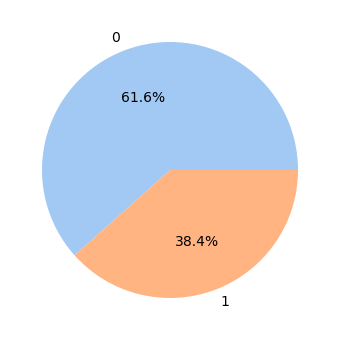

In [21]:
survive_count = cleaned_titanic_train['Survived'].value_counts()
survive_label = survive_count.index
plt.pie(survive_count, labels = survive_label, autopct = '%.1f%%')
plt.show()

From the pie chart above, the survival ratio is 2:3.

#### Passenger Age

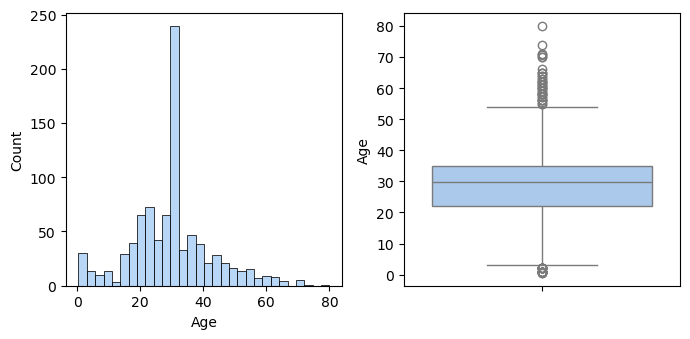

In [22]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_titanic_train, x='Age', ax=axes[0])
sns.boxplot(cleaned_titanic_train, y='Age', ax=axes[1])
plt.show()

- Most passengers are around 20-40 years old.
- There also many old people and infants.

#### Passenger Age and Survival

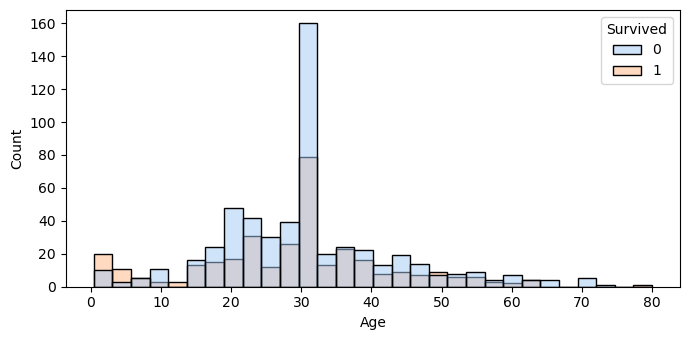

In [23]:
sns.histplot(cleaned_titanic_train, x = 'Age', hue = 'Survived')
plt.show()

Only infants have a higher survival rate.

In other age groups, there are more people dead than survival.

#### Distribution of Ticket Price

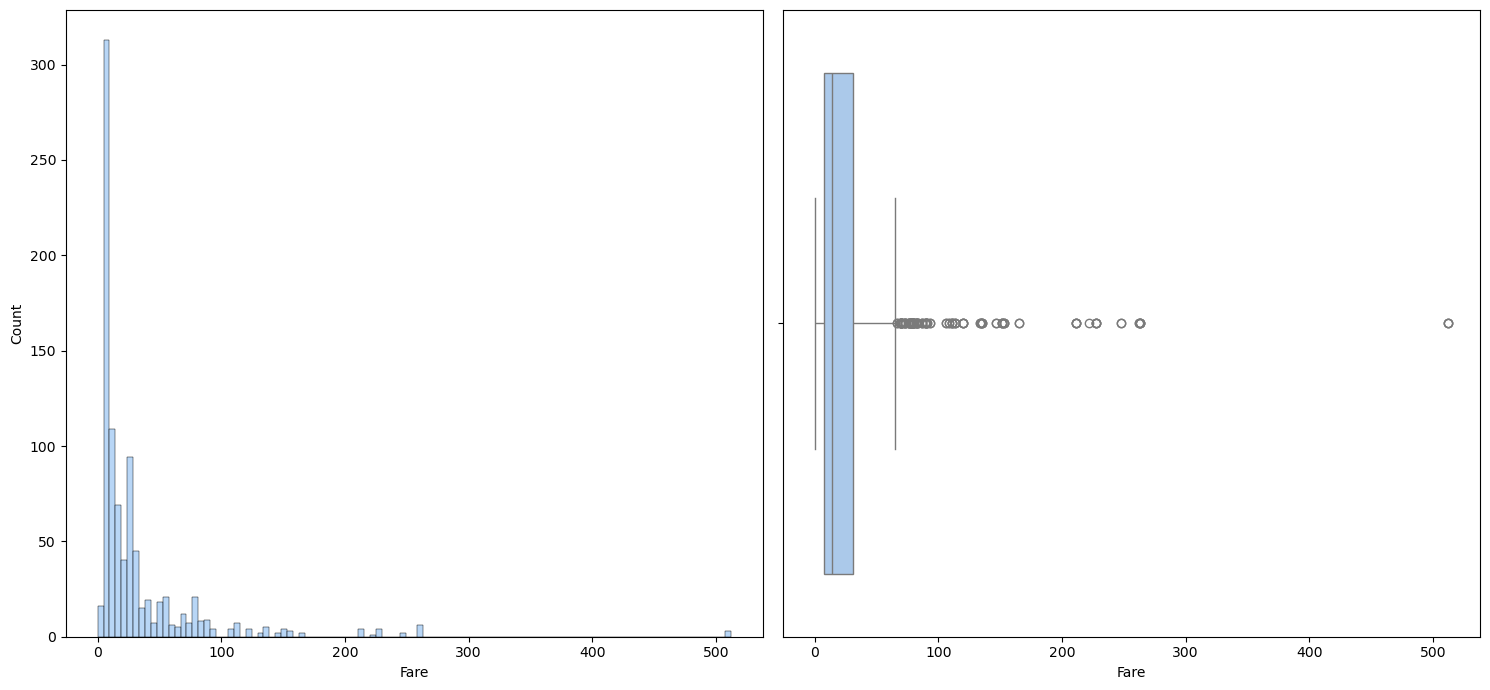

In [24]:
figure, axes = plt.subplots(1, 2, figsize = [15, 7])
sns.histplot(cleaned_titanic_train, x = 'Fare', ax = axes[0])
sns.boxplot(cleaned_titanic_train, x = 'Fare', ax = axes[1])
plt.show()

From the graphs above, we can see that:
- The distribution is right-skewed.
- Most tickets are medium priced, while a little are extremely highly priced.

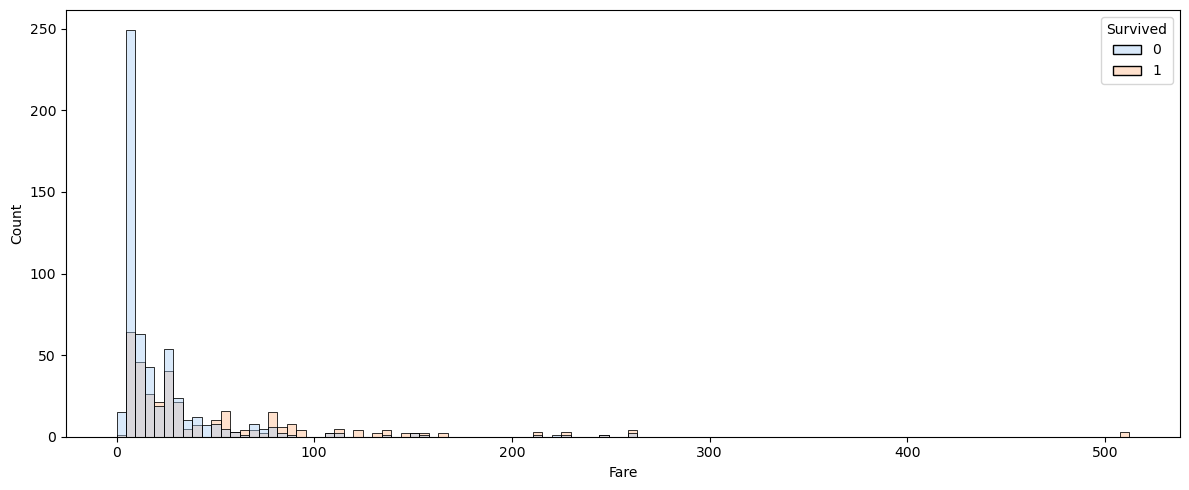

In [25]:
plt.subplots(1, 1, figsize=[12, 5])
sns.histplot(cleaned_titanic_train, x='Fare', hue='Survived', alpha=0.4)
plt.show()

We also checked the relationship between ticket price and survival rate.

We can see that: The survival rate in higher in a higher price range.

#### Passenger Class and Survival

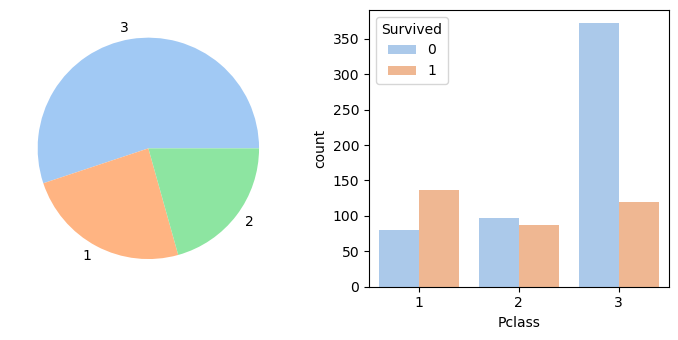

In [26]:
figur, axes = plt.subplots(1, 2)
pclass_count = cleaned_titanic_train['Pclass'].value_counts()
pclass_label = pclass_count.index
axes[0].pie(pclass_count, labels = pclass_label)
sns.countplot(cleaned_titanic_train, x = 'Pclass', hue = 'Survived', ax = axes[1])
plt.show()

As shown on the graph, we can see that:
- Most passengers are in class 3.
- The survival rate in class 3 is the lowest.

#### Sex and Survival

<Axes: xlabel='Sex', ylabel='count'>

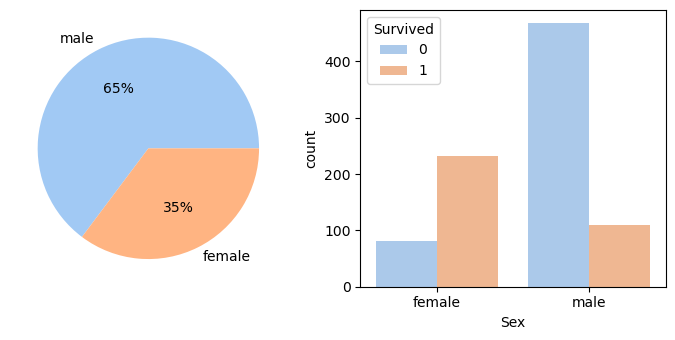

In [27]:
figure, axes = plt.subplots(1, 2)
sex_count = cleaned_titanic_train['Sex'].value_counts()
sex_label = sex_count.index
axes[0].pie(sex_count, labels = sex_label, autopct = '%1.f%%')
sns.countplot(cleaned_titanic_train, x = 'Sex', hue = 'Survived', ax = axes[1])

From the graph above:
- Male and Female is nealy 2:1
- The survival rate among male is way lower than female.

#### Embarked Port and Survival

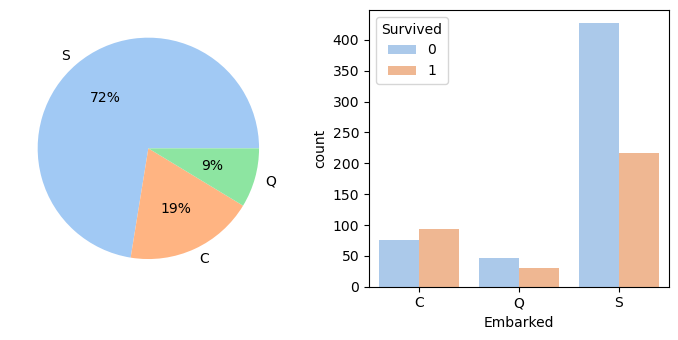

In [28]:
figure, axes = plt.subplots(1, 2)
embarked_count = cleaned_titanic_train['Embarked'].value_counts()
embarked_label = embarked_count.index
axes[0].pie(embarked_count, labels = embarked_label, autopct = '%1.f%%')
sns.countplot(cleaned_titanic_train, x = 'Embarked', hue = 'Survived', ax = axes[1])
plt.show()

From the charts above, we can see:
- Most passengers board from `South Ampton`
- The survival rate is the lowest among passengers board from `South Ampton`

#### Number of Family Members and Survival

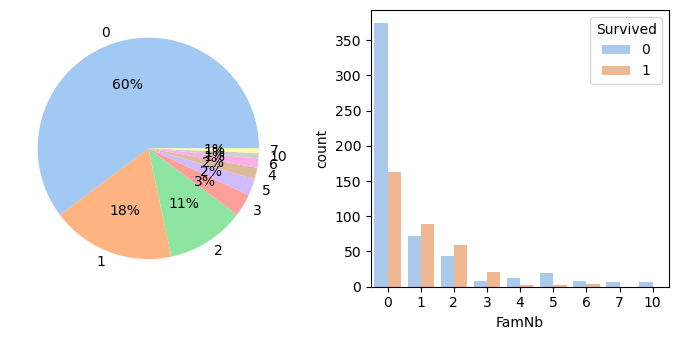

In [29]:
figure, axes = plt.subplots(1, 2)
famnb_count = cleaned_titanic_train['FamNb'].value_counts()
famnb_label = famnb_count.index
axes[0].pie(famnb_count, labels = famnb_label, autopct = '%1.f%%')
sns.countplot(cleaned_titanic_train, x = 'FamNb', hue = 'Survived', ax = axes[1])
plt.show()

From the charts above, we can see that:
- 60% passengers did not take any family members.
- Among those 60%, the servival rate is extreme low.
- Within the passengers who took family members, if the family mamber number is 1-3, the survival rate is higher than the death rate.


In [30]:
cleaned_titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    object  
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
 12  FamNb        891 non-null    int64   
dtypes: category(4), float64(2), int64(3), object(4)
memory usage: 66.8+ KB


### Analysis

In this project, logistic regression will be applied.

First, import the package needed.

In [31]:
import statsmodels.api as sm

A new variable `lr_titanic_train` will be established as a copy of `cleaned_titanic_train`. The following pre-processing and analysis processes will be done on the `lr_titanic_train`.

In [32]:
lr_titanic_train = cleaned_titanic_train.copy()
lr_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamNb
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


After consideration, some variables will be removed:
- `Name`
- `PassengerId`
- `Ticket`
- `Cabin`
- `Embarked`
- `SibSp`
- `Parch`

Since they are not relevant enough.

In [33]:
lr_titanic_train = lr_titanic_train.drop(['PassengerId', 'SibSp', 'Parch', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis = 1)
lr_titanic_train.head()

,Survived,Pclass,Sex,Age,Fare,FamNb
0,0,3,male,22.0,7.2500,1
1,1,1,female,38.0,71.2833,1
2,1,3,female,26.0,7.9250,0
3,1,1,female,35.0,53.1000,1
4,0,3,male,35.0,8.0500,0


We need to import dummy variables for `Pclass` and `Sex`.

In [34]:
lr_titanic_train = pd.get_dummies(lr_titanic_train, drop_first = True, columns = ['Pclass', 'Sex'], dtype = int)

In [35]:
lr_titanic_train

,Survived,Age,Fare,FamNb,Pclass_2,Pclass_3,Sex_male
0,0,22.000000,7.2500,1,0,1,1
1,1,38.000000,71.2833,1,0,0,0
2,1,26.000000,7.9250,0,0,1,0
3,1,35.000000,53.1000,1,0,0,0
4,0,35.000000,8.0500,0,0,1,1
...,...,...,...,...,...,...,...
886,0,27.000000,13.0000,0,1,0,1
887,1,19.000000,30.0000,0,0,0,0
888,0,29.699118,23.4500,3,0,1,0
889,1,26.000000,30.0000,0,0,0,1


In [36]:
y = lr_titanic_train['Survived']
X = lr_titanic_train.drop(['Survived'], axis = 1)

In [37]:
X.head()

,Age,Fare,FamNb,Pclass_2,Pclass_3,Sex_male
0,22.0,7.2500,1,0,1,1
1,38.0,71.2833,1,0,0,0
2,26.0,7.9250,0,0,1,0
3,35.0,53.1000,1,0,0,0
4,35.0,8.0500,0,0,1,1


Normally, if the correlation coefficient is bigger than 0.8, we will consider the two variables have strong co-linearity. One of them need to be eliminated.

In [38]:
X.corr().abs() > 0.8

,Age,Fare,FamNb,Pclass_2,Pclass_3,Sex_male
Age,True,False,False,False,False,False
Fare,False,True,False,False,False,False
FamNb,False,False,True,False,False,False
Pclass_2,False,False,False,True,False,False
Pclass_3,False,False,False,False,True,False
Sex_male,False,False,False,False,False,True


Next, a constant variable will be added.

In [39]:
X = sm.add_constant(X)

Next, `Logit` function will be applied to build the model.

In [40]:
model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.443547
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      884
Method:                           MLE   Df Model:                            6
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                  0.3339
Time:                        21:18:19   Log-Likelihood:                -395.20
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 1.786e-82
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8097      0.445      8.568      0.000       2.938       4.681
Age           -0.0388      0.008     -4.963      0.000      -0.054      -0.023
Fare           0.0032      0.002      1.311      0.190      -0.002       0.008
FamNb         -0.2430      0.068     -3.594      0.000      -0.376      -0.110
Pclass_2      -1.0003      0.293     -3.416      0.001      -1.574      -0.426
Pclass_3      -2.1324      0.289     -7.373      0.000      -2.699      -1.566
Sex_male      -2.7759      0.199    -13.980      0.000      -3.165      -2.387
==============================================================================
"""

As shown in the model summary, the variable `Fare` shows a p-value bigger than 0.05, which means it does not have significant influence on our target variable.

Then, we eliminate `Fare` and run the model again.

In [41]:
X = X.drop(['Fare'], axis = 1)
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.444623
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      885
Method:                           MLE   Df Model:                            5
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                  0.3323
Time:                        21:18:19   Log-Likelihood:                -396.16
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 4.927e-83
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0620      0.404     10.049      0.000       3.270       4.854
Age           -0.0395      0.008     -5.065      0.000      -0.055      -0.024
FamNb         -0.2186      0.065     -3.383      0.001      -0.345      -0.092
Pclass_2      -1.1798      0.261     -4.518      0.000      -1.692      -0.668
Pclass_3      -2.3458      0.242     -9.676      0.000      -2.821      -1.871
Sex_male      -2.7854      0.198    -14.069      0.000      -3.173      -2.397
==============================================================================
"""

From the model summary, we found that the following variables will negatively affect the survival possibility:
- Age
- Family member number
- Not in First Class
- Male

To understant the meaning of each coefficients, we need to calculate the power of $e$.

In [42]:
## Age
np.exp(-0.0395)

np.float64(0.9612699539905982)

From the result above, as the age increase 1 year, the survival rate will decrease about 4%.

In [43]:
## FamNb
np.exp(-0.2186)

np.float64(0.803643111115195)

From the result above, if the passenger takes one more family member, the survival rate will decrease about 20%.

In [44]:
## Pclass_2
np.exp(-1.1798)

np.float64(0.30734020049483596)

From the result above, if the [assenger is in Class 2, the survival rate will decrease about 69%.


In [45]:
## Pclass_3
np.exp(-2.3458)

np.float64(0.09577055503172162)

From the result above, if the passenger is in Class 3, his or her survival rate will be only about 10%.

In [46]:
## Sex
np.exp(-2.7854)

np.float64(0.061704402333015156)

From the result above, male passenger's survival rate is about 94% lower than female passengers.

So, we can summarize that:
- Younger passengers have higher survival rate.
- Female passengers have higher survival rate.
- Passengers who take fewer family members has higher survival rate.
- Passengers who are in higher class have higher survival rate.


### Discussion

Referring to the possible reasons behind:
- People priortized women and children while escaping.
- While escaping, people's attention could be distracted by their family members.
- Passengers in higher class may have priority to escape.

### Forecasting

Import `titanic_test.csv` as `titanic_test`.

In [47]:
titanic_test = pd.read_csv('titanic_test.csv')
titanic_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


First, of all, we need to check if there are missing values in the testing set.

In [48]:
titanic_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


From the result above:
- There are 418 observations in total.
- In `Age`, `Fare` and `Cabin`, there are missing values.

We fill the null value in `Age` with the average age.

In [49]:
mean_age = titanic_test['Age'].mean()
titanic_test['Age'] = titanic_test['Age'].fillna(mean_age)

We need to create a new variable `FamNb`, as the sum of `SibSp` and `Parch`.

In [50]:
titanic_test['FamNb'] = titanic_test['SibSp'] + titanic_test['Parch']
titanic_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  FamNb        418 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


Since we do not need to consider `Fare` and `Cabin` in our forecasting model, we can drop these two variables along with other variables that is not valuable" `PassengerId`, `Name`, `SibSp`, `Parch`, `Ticket` and `Embarked`.

In [51]:
titanic_test = titanic_test.drop(['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch', 'Cabin', 'Fare', 'Embarked'], axis = 1)

In [52]:
titanic_test.head()

,Pclass,Sex,Age,FamNb
0,3,male,34.5,0
1,3,female,47.0,1
2,2,male,62.0,0
3,3,male,27.0,0
4,3,female,22.0,2


We import dummy variables for `Pclass` and `Sex`.

But first, we need to make sure every categorical data involve all the categories.

In [53]:
titanic_test['Pclass'] = pd.Categorical(titanic_test['Pclass'], categories = ['1','2','3'])
titanic_test['Sex'] = pd.Categorical(titanic_test['Sex'], categories = ['female', 'male'])

In [54]:
titanic_test = pd.get_dummies(titanic_test, drop_first = True, columns = ['Pclass', 'Sex'], dtype = int)
titanic_test.head()

,Age,FamNb,Pclass_2,Pclass_3,Sex_male
0,34.5,0,0,0,1
1,47.0,1,0,0,0
2,62.0,0,0,0,1
3,27.0,0,0,0,1
4,22.0,2,0,0,0


In [55]:
X_test = titanic_test.copy()
X_test = sm.add_constant(X_test)

Now we apply the model on the testing set.

In [56]:
predicted_value = model.predict(X_test)
predicted_value

0      0.478514
1      0.879434
2      0.236473
3      0.552361
4      0.940242
         ...   
413    0.520230
414    0.925647
415    0.439306
416    0.520230
417    0.411858
Length: 418, dtype: float64

Now we get the predicted survival rate for the passengers in `titanic_test.csv`. We can consider the passenger dead if the survival rate is lower than 0.5.

In [57]:
predicted_value < 0.5

0       True
1      False
2       True
3      False
4      False
       ...  
413    False
414    False
415     True
416    False
417     True
Length: 418, dtype: bool